In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import levy_stable
import powerlaw
import math
from datetime import datetime

def pl_fit(data):
    """
    Calculate exponent of powerlaw and standard deviation of parameter uncertainty for alpha
    """
    result = powerlaw.Fit(data).power_law
    alpha = result.alpha
    sigma = result.sigma

    return alpha, sigma

def crit_params(data):
    """
    Fit data to Levy stable distribution and output alpha and beta estimates.
    Alpha is the stability parameter and beta is the skewness parameter.
    """

    alpha_est, beta_est, loc_est, scale_est = levy_stable.fit(data)
    return alpha_est, beta_est

## Choose equity index to be analysed

In [3]:
sourcefile = 'Data/S&P500/SP500_2016-2024_daily.csv'
index_name = 'S&P500'

In [ ]:
sourcefile = 'Data/NIKKEI/Nikkei225_2010-2024 daily.csv'
index_name = 'NIKKEI'

## Clean data

In [10]:
df = pd.read_csv(sourcefile)
dates = pd.to_datetime(df['Date'], format='mixed')
df['Date'] = dates.dt.strftime('%Y-%m-%d')
print(df.head())

         Date  Close/Last     Volume    Open    High     Low
0  2016-01-04    201.0192  221450500  200.49  201.03  198.59
1  2016-01-05    201.3600  110381200  201.40  201.90  200.05
2  2016-01-06    198.8200  151636700  198.34  200.06  197.60
3  2016-01-07    194.0500  212565100  195.33  197.44  193.59
4  2016-01-08    191.9230  209524400  195.19  195.85  191.58


## Visualise returns distribution

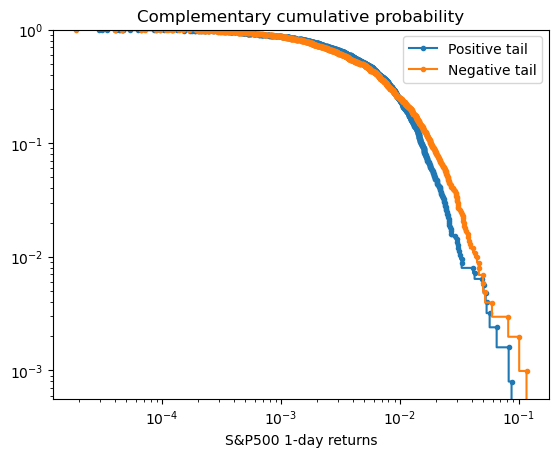

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 1252, 1011
3.873133135519324+-0.22035925232405887, 3.1820900460602637+-0.1640159315865707


In [11]:
# Power law tail starting point
cutoff = 1E-2

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j,price in enumerate(df['Close/Last']):
    if j < len(df['Close/Last'])-1:
        r=math.log(df['Close/Last'][j+1]) - math.log(price)
        if r>=0:
            gains.append(r)
            if r>=cutoff:
                filteredgains.append(r)
        else:
            losses.append(abs(r))
            if r<=-cutoff:
                filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title('Complementary cumulative probability')
plt.xlabel(f'{index_name} 1-day returns')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

## Estimation of Levy stable parameters

### 1 day before 20 Feb 2020 global stock market crash

In [12]:
# Set time window of our study
crisisdate = '2020-02-20' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
windowrowend = crisisrow - 1 # Row in df corresponding to end of window, ie. 1 day before the crisis
windowrowstart = crisisrow - 1 - window # Row in df corresponding to start of window
windowprices = np.array(df['Close/Last'].iloc[windowrowstart:windowrowend])
filteredreturns = []
returns = []

# Find the 'return' r
for j, price in enumerate(windowprices):
    if j < len(windowprices)-1:
        r = math.log(windowprices[j+1]) - math.log(price)

        returns.append(r)

print(f'no. of {index_name} returns = {len(returns)}')
print(f'time period of window: {df['Date'].iloc[windowrowstart]} to {df['Date'].iloc[windowrowend]}')
print(f'alpha, beta = {crit_params(returns)}')

no. of S&P500 returns = 499
time period of window: 2018-02-22 to 2020-02-19
alpha, beta = (np.float64(1.6134684257560916), np.float64(-0.4293631004970137))


### On different days before 20 Feb 2020 global stock market crash

In [ ]:
days_grid = [30, 20, 10, 5, 1] # No. of market days before crisis. Minimum value is 1
crisisdate = '2020-02-20' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
alphas = []
betas = []

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

for days_bef_crisis in days_grid:
    windowrowend = crisisrow - days_bef_crisis
    windowrowstart = crisisrow - days_bef_crisis - window
    windowprices = np.array(df['Close/Last'].iloc[windowrowstart:windowrowend])

    returns = []

    # Find the return, r
    for j, price in enumerate(windowprices):
        if j < len(windowprices)-1:
            r = math.log(windowprices[j+1]) - math.log(price)

            returns.append(r)

    print(f'Calculation of returns for days_bef_crisis={days_bef_crisis} done.')
    alpha, beta = crit_params(returns)
    print(f'days_bef_crisis={days_bef_crisis}, alpha={alpha}, beta={beta}')
    alphas.append(alpha)
    betas.append(beta)
ax1.plot(days_grid, alphas, color='c', marker='.', label='α')
ax2.plot(days_grid, betas, color = 'm', marker='.', label='β')
fig.suptitle(f'Estimated Levy stable distribution parameters for {index_name}')
ax1.set_xlabel('Days before crisis')
ax2.set_xlabel('Days before crisis')
ax1.legend()
ax2.legend()
plt.show()
plt.savefig(f'Results/{index_name}_params_30days.png')